In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load training and testing datasets directly
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")

# Inspect first few rows
train_df.head()

Train Dataset Shape: (1296675, 23)
Test Dataset Shape:  (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# Check target distribution
print("Fraud Class Distribution (Train):")
print(train_df['is_fraud'].value_counts())
print("\nPercentage:")
print(train_df['is_fraud'].value_counts(normalize=True) * 100)

# Check missing values
print("\nMissing Values:")
print(train_df.isnull().sum().sum())

Fraud Class Distribution (Train):
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

Missing Values:
0


In [4]:
# Function to extract features and clean data
def preprocess_data(df):
    df = df.copy()
    
    # Convert transaction time to datetime and extract features
    df['trans_date_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_time'].dt.hour
    df['day'] = df['trans_date_time'].dt.day
    df['dayofweek'] = df['trans_date_time'].dt.dayofweek
    df['month'] = df['trans_date_time'].dt.month
    
    # Calculate age from DOB if present
    if 'dob' in df.columns:
        df['dob'] = pd.to_datetime(df['dob'])
        df['age'] = (df['trans_date_time'] - df['dob']).dt.days // 365
    
    # Drop unnecessary/high-cardinality identifier columns
    drop_cols = [
        'Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'first', 'last', 
        'street', 'city', 'state', 'zip', 'dob', 'trans_num', 'trans_date_time', 'job'
    ]
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    return df

train_clean = preprocess_data(train_df)
test_clean = preprocess_data(test_df)

# Target encoding or One-Hot Encoding for categorical features (category, gender, merchant)
categorical_cols = ['category', 'gender', 'merchant']
train_clean = pd.get_dummies(train_clean, columns=categorical_cols, drop_first=True)
test_clean = pd.get_dummies(test_clean, columns=categorical_cols, drop_first=True)

# Align train and test columns (ensures identical feature sets)
train_clean, test_clean = train_clean.align(test_clean, join='left', axis=1, fill_value=0)

print("Preprocessed Train shape:", train_clean.shape)
print("Preprocessed Test shape:", test_clean.shape)

Preprocessed Train shape: (1296675, 719)
Preprocessed Test shape: (555719, 719)


In [5]:
X_train = train_clean.drop(columns=['is_fraud'])
y_train = train_clean['is_fraud']

X_test = test_clean.drop(columns=['is_fraud'])
y_test = test_clean['is_fraud']

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (1296675, 718)
Testing Features: (555719, 718)


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize Decision Tree with class balancing
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=12, random_state=42)

print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n--- Decision Tree Performance ---")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_dt):.4f}")

Training Decision Tree...

--- Decision Tree Performance ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.14      0.95      0.25      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.96      0.62    555719
weighted avg       1.00      0.98      0.99    555719

ROC-AUC Score: 0.9653


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Using n_estimators=50 & max_depth=15 to balance speed and power on large data
rf_model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=15, 
    class_weight='balanced', 
    n_jobs=-1, 
    random_state=42
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Training Random Forest...

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.14      0.75      0.24      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.87      0.61    555719
weighted avg       1.00      0.98      0.99    555719

ROC-AUC Score: 0.9643


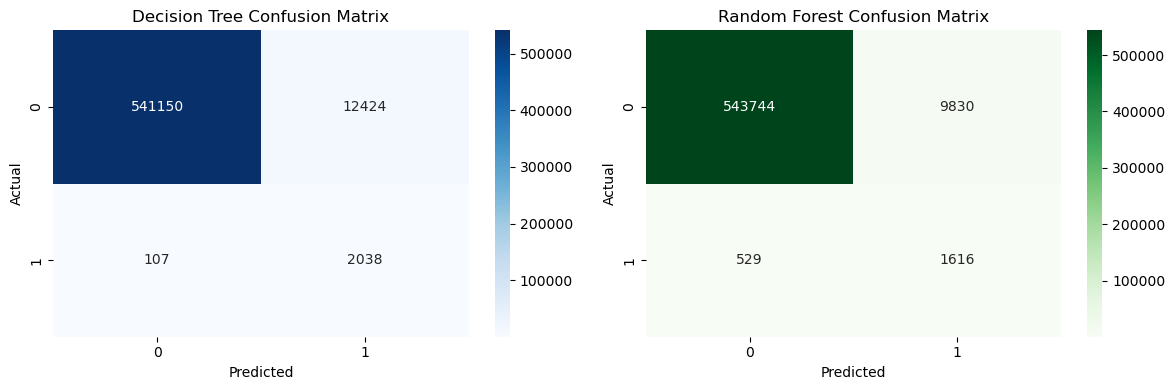

In [11]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

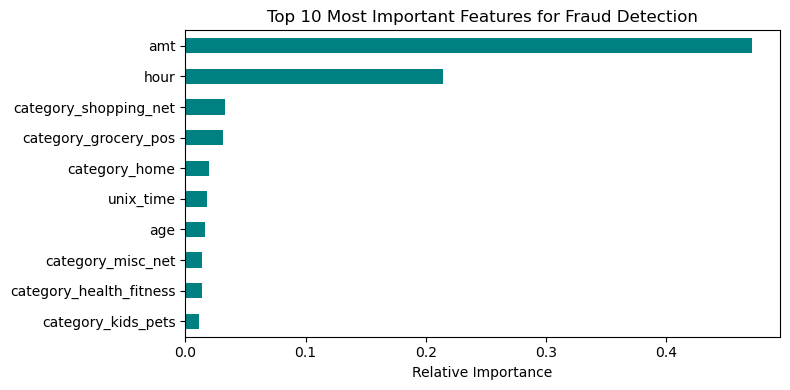

In [12]:
# Extract top 10 important features from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(8, 4))
top_10.plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()